## Import Toolkit

In [9]:
#OS libs
import os
import shutil
import itertools
import pathlib
from PIL import Image

#Data handling tools
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report

#Deep learning libs
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Flatten , Activation , Dense , Dropout , BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras import regularizers

#Warningds
import warnings
warnings.filterwarnings('ignore')

In [10]:
train_data_path = '/kaggle/input/brain-tumor-mri-dataset/Training'

filepaths =[]
labels = []

folds = os.listdir(train_data_path)

for fold in folds:
    f_path = os.path.join(train_data_path , fold)
    filelists = os.listdir(f_path)
    
    for file in filelists:
        filepaths.append(os.path.join(f_path , file))
        labels.append(fold)
        
#Concat data paths with labels
Fseries = pd.Series(filepaths , name = 'filepaths')
Lseries = pd.Series(labels , name = 'label')
train_df = pd.concat([Fseries , Lseries] , axis = 1)

In [11]:
train_df

,filepaths,label
0,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
...,...,...
5595,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5596,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5597,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5598,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma


In [12]:
test_data_path = '/kaggle/input/brain-tumor-mri-dataset/Testing'

filepaths =[]
labels = []

folds = os.listdir(test_data_path)

for fold in folds:
    f_path = os.path.join(test_data_path , fold)
    filelists = os.listdir(f_path)
    
    for file in filelists:
        filepaths.append(os.path.join(f_path , file))
        labels.append(fold)
        
#Concat data paths with labels
Fseries = pd.Series(filepaths , name = 'filepaths')
Lseries = pd.Series(labels , name = 'label')
test_df = pd.concat([Fseries , Lseries] , axis = 1)

In [13]:
test_df

,filepaths,label
0,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
...,...,...
1595,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1596,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1597,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1598,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma


## Split Data into Valid and Test

In [14]:
valid , test = train_test_split(test_df , train_size = 0.5 , shuffle = True , random_state= 42)

## Image Data Generator

In [45]:
img_size = (224 ,244)
batch_size = 16

tr_gen = ImageDataGenerator()
ts_gen= ImageDataGenerator()

train_gen = tr_gen.flow_from_dataframe(train_df , x_col = 'filepaths' , y_col = 'label' , target_size = img_size ,
                                      class_mode = 'categorical' , color_mode = 'rgb' , shuffle = True , batch_size =batch_size)

valid_gen = ts_gen.flow_from_dataframe(valid , x_col = 'filepaths' , y_col = 'label' , target_size = img_size , 
                                       class_mode = 'categorical',color_mode = 'rgb' , shuffle= True, batch_size = batch_size)

test_gen = ts_gen.flow_from_dataframe(test , x_col= 'filepaths' , y_col = 'label' , target_size = img_size , 
                                      class_mode = 'categorical' , color_mode= 'rgb' , shuffle = False , batch_size = batch_size)

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


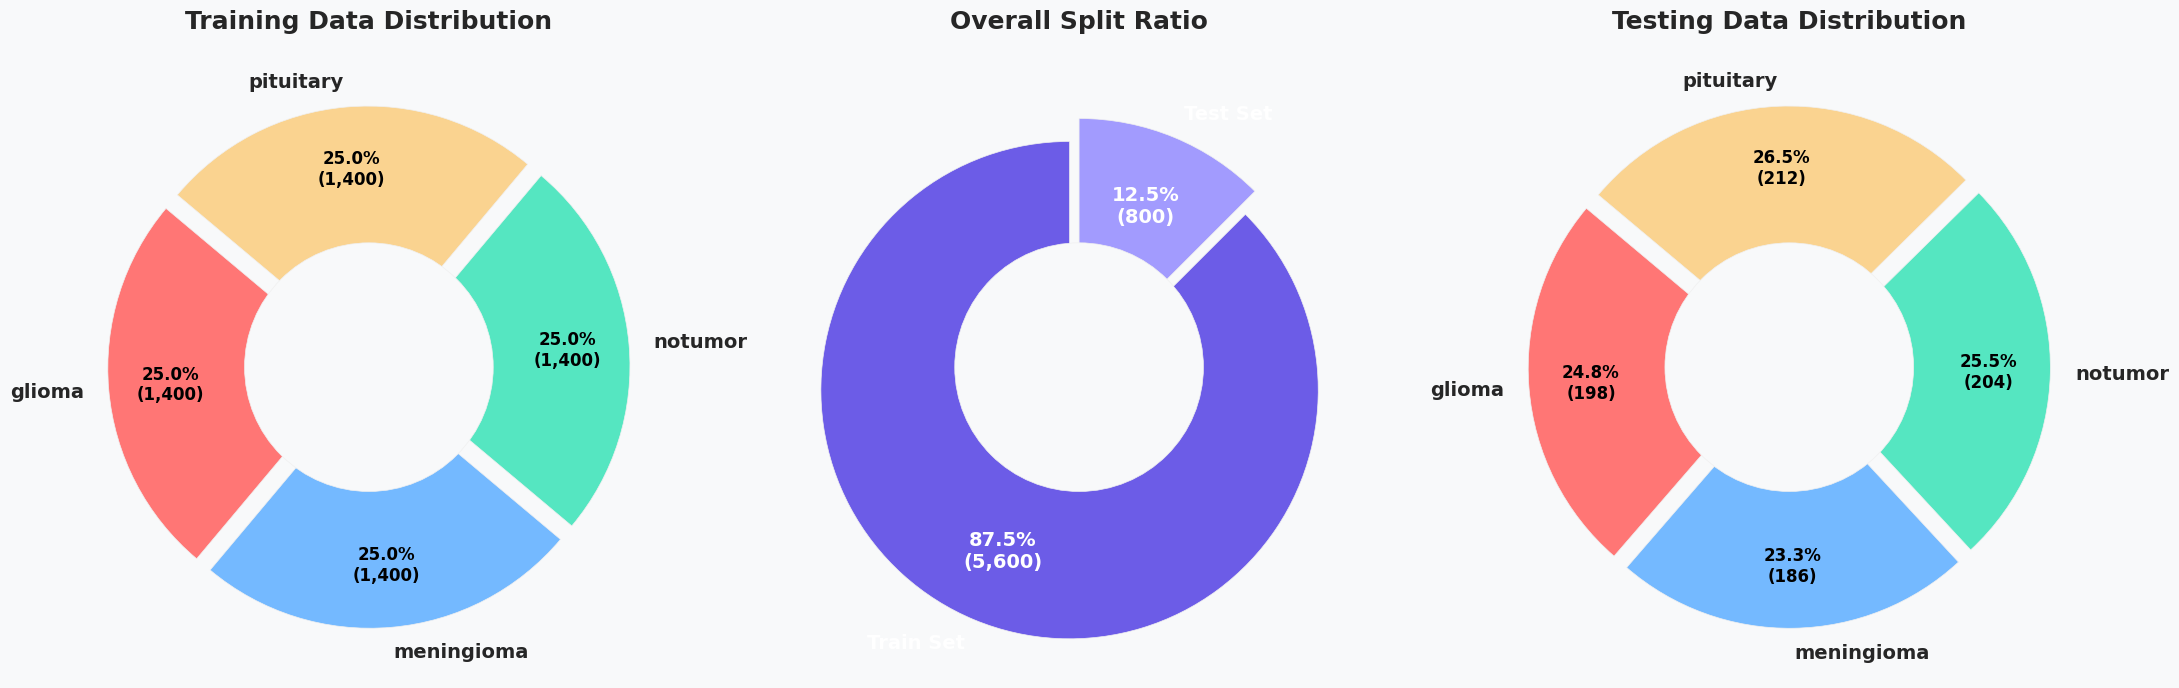

In [48]:
import matplotlib.pyplot as plt

# إعداد البيانات من train_df و test_df
class_names = list(train_gen.class_indices.keys())  # ['glioma', 'meningioma', 'notumor', 'pituitary']

train_counts = train_df['label'].value_counts()[class_names].tolist()
test_counts  = test['label'].value_counts()[class_names].tolist()

# اختيار لوحة ألوان احترافية
colors_classes = ['#FF7675', '#74B9FF', '#55E6C1', '#FAD390']
colors_split   = ['#6C5CE7', '#A29BFE']

# إنشاء الشكل العام
fig, ax = plt.subplots(ncols=3, figsize=(22, 10), facecolor='#f8f9fa')

# --- 1. توزيع بيانات التدريب ---
wedges, texts, autotexts = ax[0].pie(
    train_counts,
    labels=class_names,
    autopct=lambda p: '{:.1f}%\n({:,.0f})'.format(p, p * sum(train_counts) / 100),
    startangle=140,
    colors=colors_classes,
    pctdistance=0.75,
    explode=[0.05] * len(train_counts),
    textprops={'fontsize': 14, 'fontweight': 'bold'}
)
centre_circle = plt.Circle((0, 0), 0.50, fc='#f8f9fa')
ax[0].add_artist(centre_circle)
ax[0].set_title('Training Data Distribution', fontsize=18, fontweight='bold', pad=20)

# --- 2. تقسيم البيانات (Train vs Test) ---
ax[1].pie(
    [len(train_df), len(test)],
    labels=['Train Set', 'Test Set'],
    colors=colors_split,
    autopct=lambda p: '{:.1f}%\n({:,.0f})'.format(p, p * sum([len(train_df), len(test)]) / 100),
    startangle=90,
    explode=(0.1, 0),
    pctdistance=0.70,
    textprops={'fontsize': 14, 'fontweight': 'bold', 'color': 'white'}
)
centre_circle2 = plt.Circle((0, 0), 0.50, fc='#f8f9fa')
ax[1].add_artist(centre_circle2)
ax[1].set_title('Overall Split Ratio', fontsize=18, fontweight='bold', pad=20)

# --- 3. توزيع بيانات الاختبار ---
wedges3, texts3, autotexts3 = ax[2].pie(
    test_counts,
    labels=class_names,
    autopct=lambda p: '{:.1f}%\n({:,.0f})'.format(p, p * sum(test_counts) / 100),
    startangle=140,
    colors=colors_classes,
    pctdistance=0.75,
    explode=[0.05] * len(test_counts),
    textprops={'fontsize': 14, 'fontweight': 'bold'}
)
centre_circle3 = plt.Circle((0, 0), 0.50, fc='#f8f9fa')
ax[2].add_artist(centre_circle3)
ax[2].set_title('Testing Data Distribution', fontsize=18, fontweight='bold', pad=20)

# تحسين الأرقام داخل الدوائر
for autotext in autotexts + autotexts3:
    autotext.set_color('black')
    autotext.set_fontsize(12)

plt.tight_layout()
plt.show()

## Show sample from train data

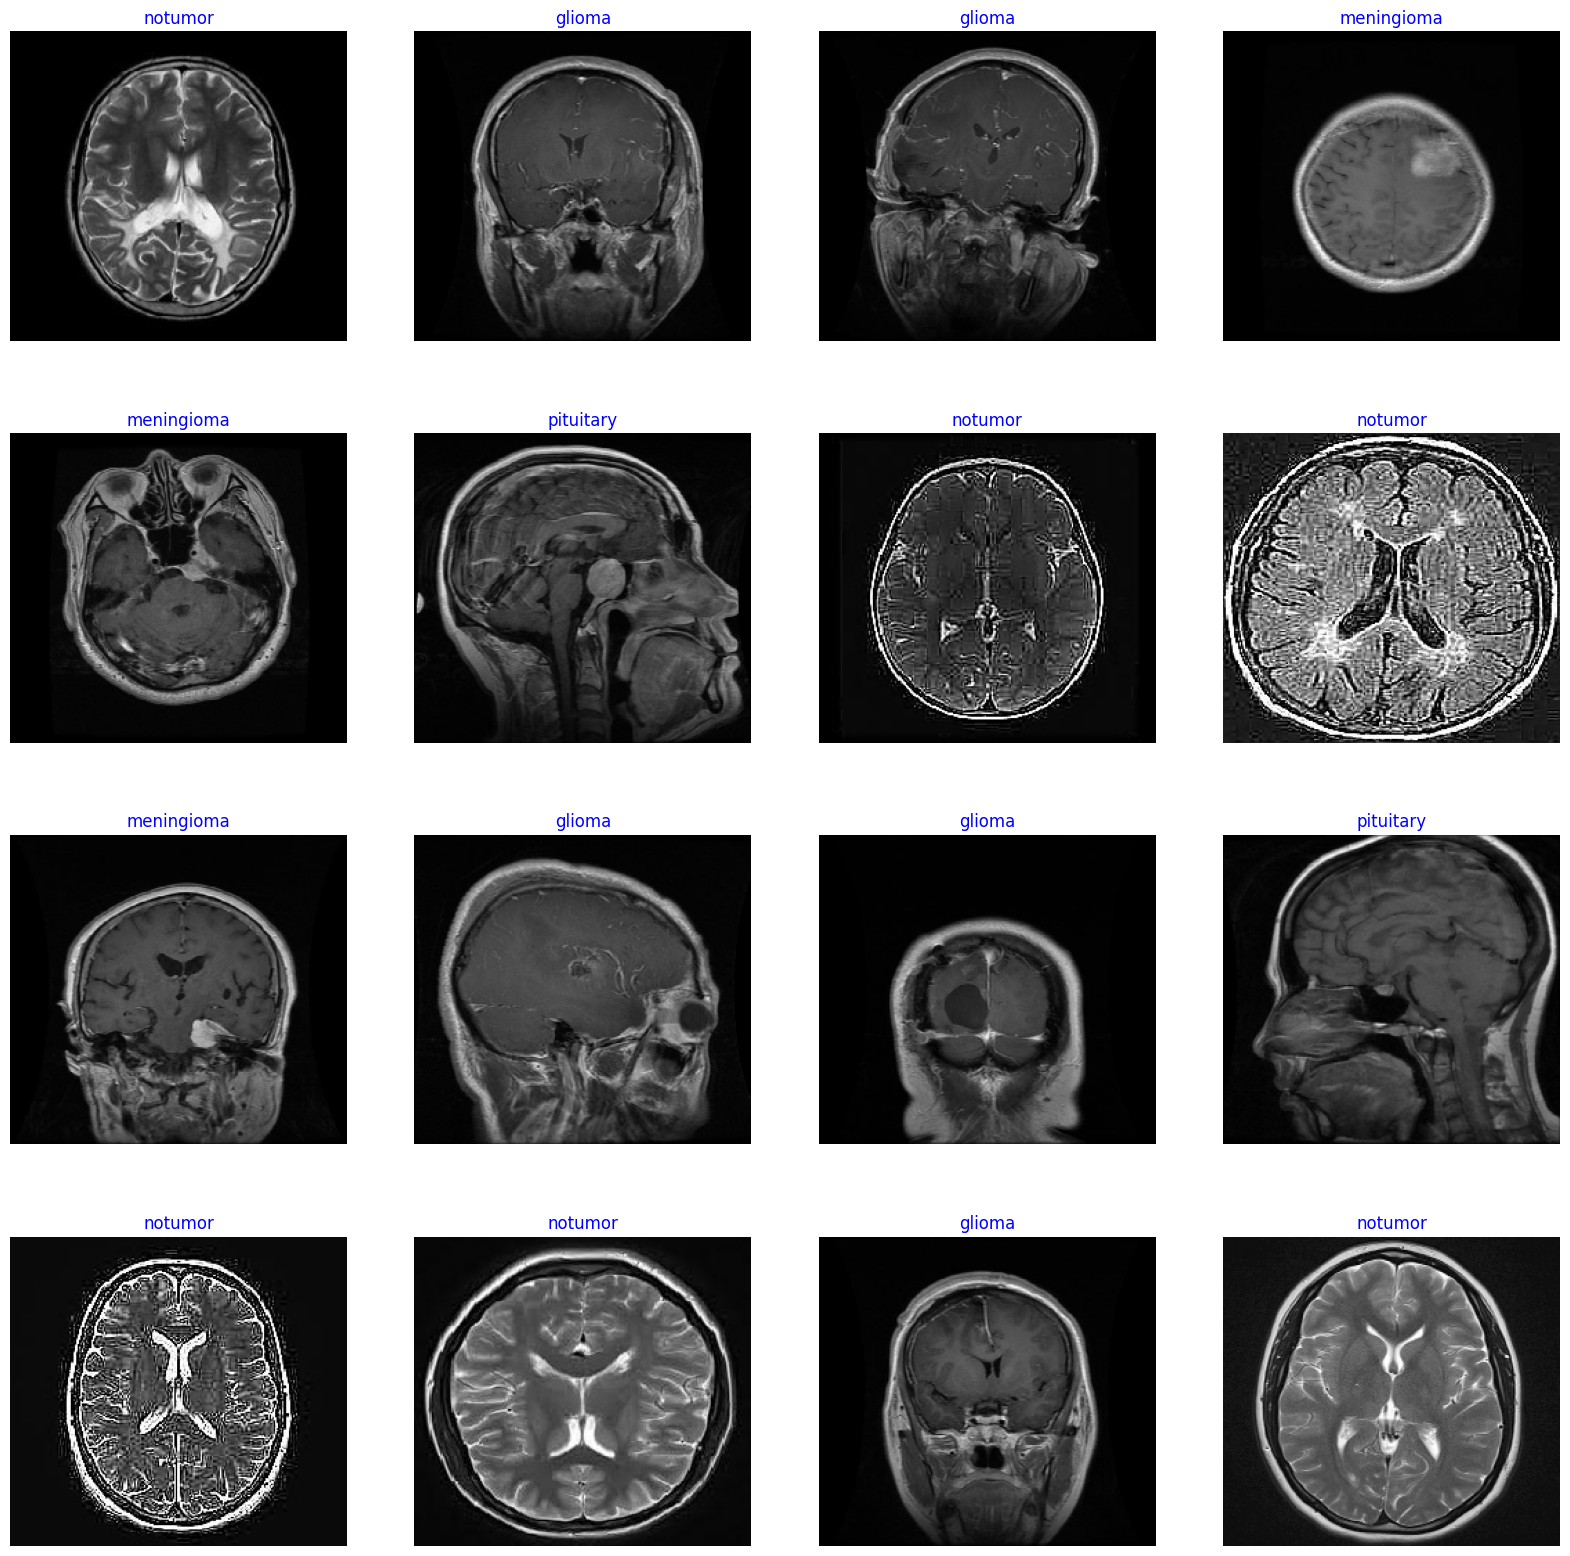

In [16]:
gen_dict = train_gen.class_indices
classes = list(gen_dict.keys())
images , labels = next(train_gen)

plt.figure(figsize= (20,20))

for i in range(16):
    plt.subplot(4,4,i+1)
    image = images[i] / 255
    plt.imshow(image)
    index = np.argmax(labels[i])
    class_name = classes[index]
    plt.title(class_name , color = 'blue' , fontsize= 12)
    plt.axis('off')
plt.show();

## Model Structure

In [17]:
img_shape = (img_size[0] , img_size[1] , 3)
num_class = len(classes)

base_model = tf.keras.applications.efficientnet.EfficientNetB3(include_top = False , weights = 'imagenet' ,
                                                               input_shape = img_shape, pooling= 'max')
model = Sequential([
    base_model,
    BatchNormalization(axis= -1 , momentum= 0.99 , epsilon= 0.001),
    Dense(256, kernel_regularizer = regularizers.l2(l= 0.016) , activity_regularizer = regularizers.l1(0.006),
         bias_regularizer= regularizers.l1(0.006) , activation = 'relu'),
    Dropout(rate= 0.4 , seed = 75),
    Dense(num_class , activation = 'softmax')
])

model.compile(Adamax(learning_rate = 0.001) , loss = 'categorical_crossentropy', metrics = ['accuracy'])
model.summary()

43941136/43941136 [==============================] - 3s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb3 (Functional)  (None, 1536)             10783535  
                                                                 
 batch_normalization (BatchN  (None, 1536)             6144      
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 256)               393472    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 4)                 1028      
                                                                 
Total params: 11,184,179
Trainable params: 11,093,804
Non

## Iterate

In [18]:
Epochs = 10

history = model.fit(x= train_gen , epochs = Epochs , verbose = 1 , validation_data = valid_gen ,
                   validation_steps = None , shuffle = False)

Epoch 1/10


2026-05-13 11:51:39.614995: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/efficientnetb3/block1b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


350/350 [==============================] - 150s 245ms/step - loss: 5.8408 - accuracy: 0.8643 - val_loss: 3.9983 - val_accuracy: 0.9025
Epoch 2/10
350/350 [==============================] - 80s 229ms/step - loss: 2.7862 - accuracy: 0.9559 - val_loss: 2.0008 - val_accuracy: 0.9413
Epoch 3/10
350/350 [==============================] - 80s 229ms/step - loss: 1.3775 - accuracy: 0.9741 - val_loss: 1.0608 - val_accuracy: 0.9400
Epoch 4/10
350/350 [==============================] - 80s 228ms/step - loss: 0.7035 - accuracy: 0.9796 - val_loss: 0.6552 - val_accuracy: 0.9400
Epoch 5/10
350/350 [==============================] - 80s 228ms/step - loss: 0.3961 - accuracy: 0.9875 - val_loss: 0.4637 - val_accuracy: 0.9425
Epoch 6/10
350/350 [==============================] - 80s 228ms/step - loss: 0.2807 - accuracy: 0.9886 - val_loss: 0.3974 - val_accuracy: 0.9425
Epoch 7/10
350/350 [==============================] - 80s 228ms/step - loss: 0.2151 - accuracy: 0.9920 - val_loss: 0.3640 - val_accuracy: 0.

## Model Performance

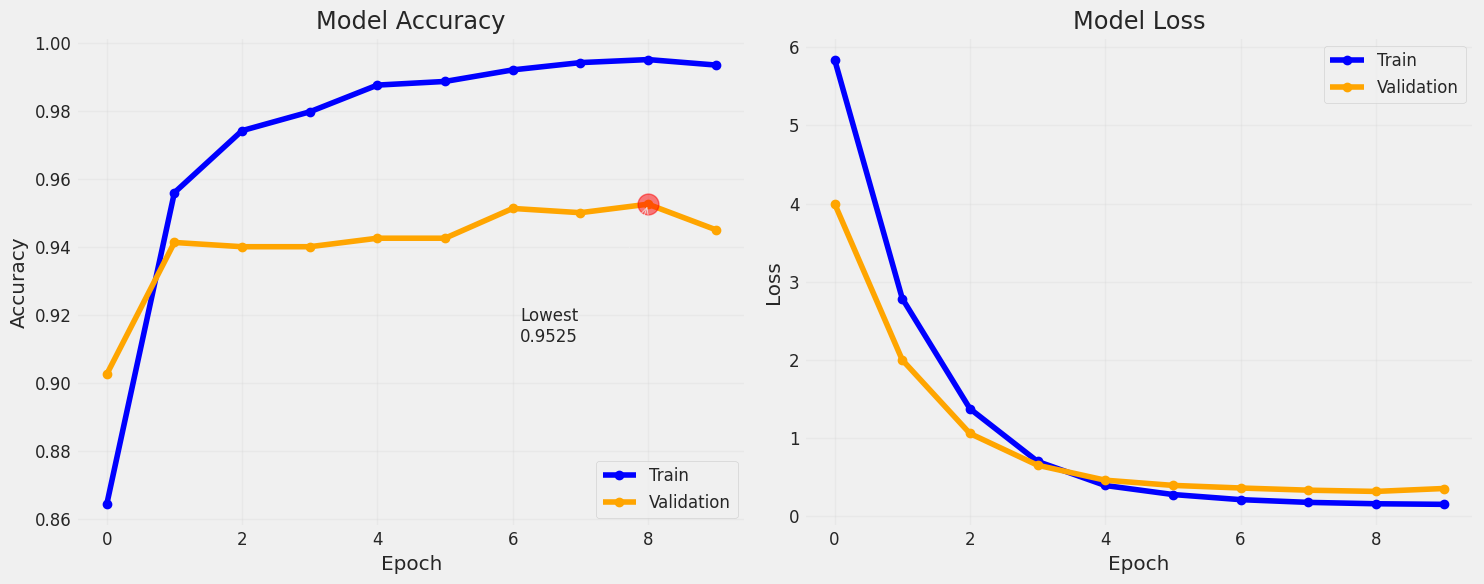

In [30]:
_, ax = plt.subplots(ncols=2, figsize=(15, 6))

# Plotting training and validation accuracy over epochs
ax[0].plot(history.history['accuracy'], marker='o', linestyle='-', color='blue')
ax[0].plot(history.history['val_accuracy'], marker='o', linestyle='-', color='orange')
ax[0].set_title('Model Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend(['Train', 'Validation'], loc='lower right')
ax[0].grid(alpha=0.2)

# Plotting training and validation loss over epochs
ax[1].plot(history.history['loss'], marker='o', linestyle='-', color='blue')
ax[1].plot(history.history['val_loss'], marker='o', linestyle='-', color='orange')
ax[1].set_title('Model Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend(['Train', 'Validation'], loc='upper right')
ax[1].grid(alpha=0.2)

# Highlight lowest validation accuracy
min_val_acc_epoch = np.argmax(history.history['val_accuracy'])
min_val_acc = np.max(history.history['val_accuracy'])
ax[0].plot(min_val_acc_epoch, min_val_acc, 'ro', markersize=15, alpha=0.5)
ax[0].annotate(f'Lowest\n{min_val_acc:.4f}', xy=(min_val_acc_epoch, min_val_acc), 
               xytext=(min_val_acc_epoch - 100, min_val_acc - 100), textcoords='offset points',
               arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2'))

plt.tight_layout()
plt.show()

## Model Evaluation

In [20]:
train_score = model.evaluate(train_gen , steps =16 , verbose = 1)
valid_score = model.evaluate(valid_gen , steps = 16 , verbose = 1)
test_score = model.evaluate(test_gen , steps = 16 , verbose = 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

16/16 [==============================] - 2s 112ms/step - loss: 0.2785 - accuracy: 0.9609
Train Loss:  0.1253349632024765
Train Accuracy:  1.0
--------------------
Validation Loss:  0.4217289686203003
Validation Accuracy:  0.92578125
--------------------
Test Loss:  0.27851682901382446
Test Accuracy:  0.9609375


## Model Prediction

## Confusion Matrix and Classification Report

In [21]:
preds = model.predict_generator(test_gen)

y_pred = np.argmax(preds , axis = 1)

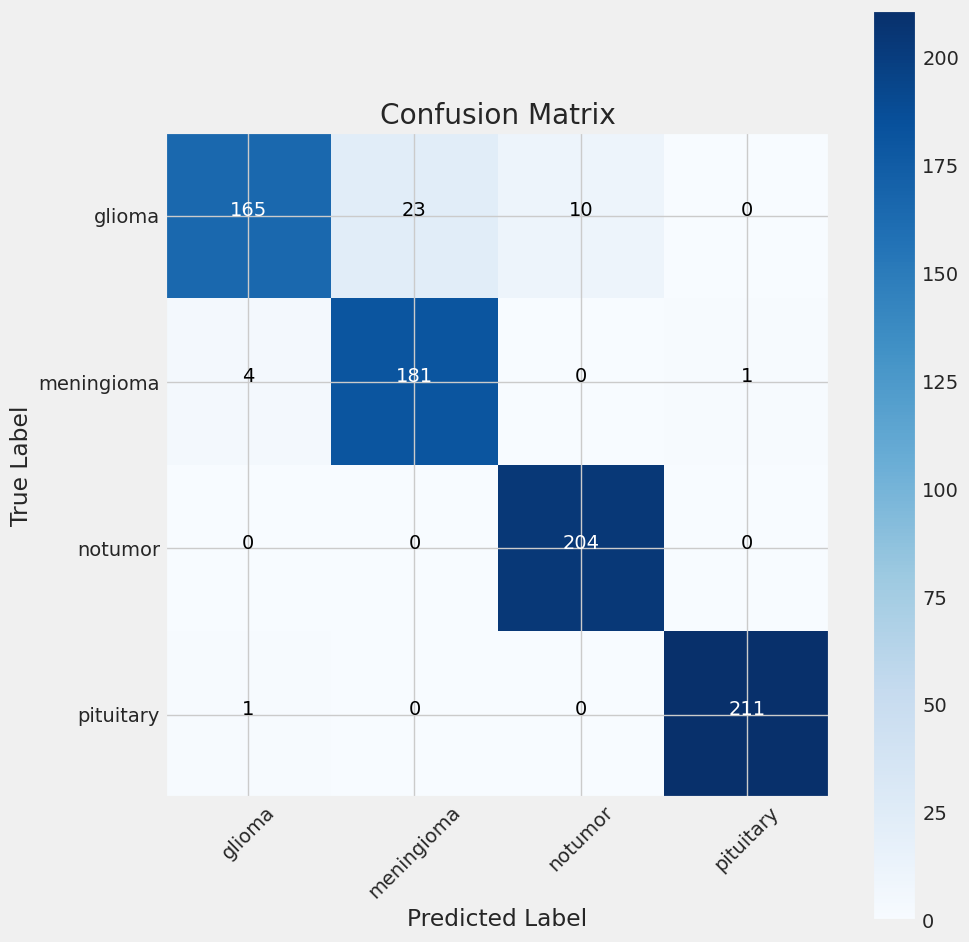

In [22]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [23]:
#Classification Report
print(classification_report(test_gen.classes, y_pred , target_names= classes ))

              precision    recall  f1-score   support

      glioma       0.97      0.83      0.90       198
  meningioma       0.89      0.97      0.93       186
     notumor       0.95      1.00      0.98       204
   pituitary       1.00      1.00      1.00       212

    accuracy                           0.95       800
   macro avg       0.95      0.95      0.95       800
weighted avg       0.95      0.95      0.95       800



In [ ]:
def plot_misclassified_samples(model, dataset, index_to_class, figsize=(10, 6)):
    misclassified_images = []
    misclassified_predictions = []
    misclassified_labels = []  

    dataset.reset()

    for _ in range(len(dataset)):
        image_batch, true_label_batch = next(dataset)

        predictions = model.predict(image_batch, verbose=False)
        predicted_labels = np.argmax(predictions, axis=1)
        true_labels = np.argmax(true_label_batch, axis=1)

        for img, true, pred in zip(image_batch, true_labels, predicted_labels):
            if true != pred:
                misclassified_images.append(img)
                misclassified_labels.append(index_to_class[true])      
                misclassified_predictions.append(index_to_class[pred]) 

    num_misclassified = len(misclassified_images)
    if num_misclassified == 0:
        print("No misclassified images found!")
        return

    cols = 5
    rows = num_misclassified // cols + (num_misclassified % cols > 0)

    miss_classified_zip = zip(misclassified_images, misclassified_labels, misclassified_predictions)  
    plt.figure(figsize=figsize)
    for i, (image, true_label, predicted_label) in enumerate(miss_classified_zip):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(image.astype('uint8'))
        plt.title(f'True: {true_label}\nPred: {predicted_label}', fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


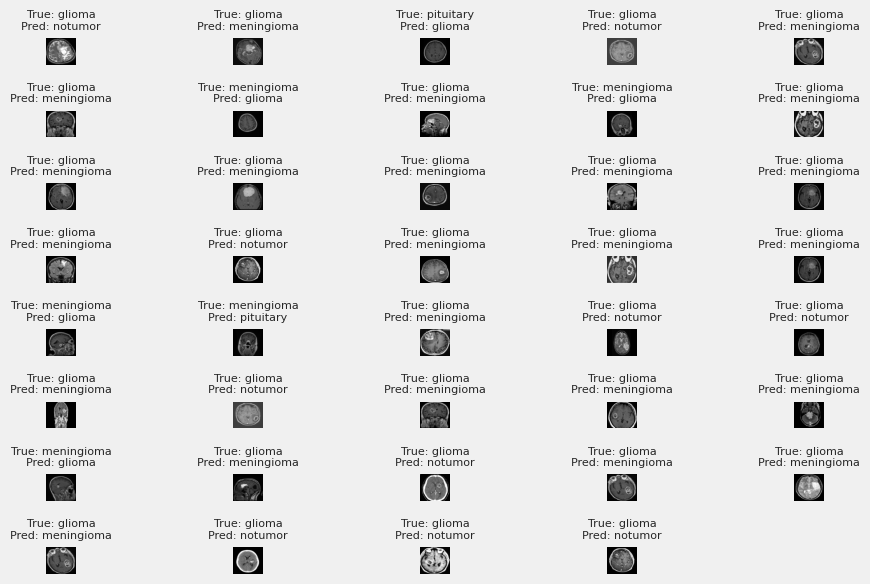

In [41]:
# اطبع gen_dict الأول تشوف شكله
print(gen_dict)

# اقلبه
index_to_class = {v: k for k, v in gen_dict.items()}

# ثم مرره
plot_misclassified_samples(
    model=model,
    dataset=test_gen,
    index_to_class=index_to_class,
    figsize=(10, 6)
)